# **Hands on III**

Assignment done by Diego Maquieira Vidal (diego.maquieira01@estudiant.upf.edu), Brigita Medelyte (brigita.medelyte01@estudiant.upf.edu) & Tanner Alexander Garcia (tanneralexander.garcia01@estudiant.upf.edu)


The datasets originate from the study  [**Proteomic and Metabolomic Characterization of COVID-19 Patient Sera**](https://www.sciencedirect.com/science/article/pii/S0092867420306279). 

## Table of Contents

- [Imports & Setup](#imports-setup)
  - [Load clinical labels](#load-clinical-labels)
  - [Load and clean training data](#load-and-clean-training-data)
    - [Parse feature IDs as row index, patient IDs as column names](#parse-feature-ids-as-row-index-patient-ids-as-column-names)
    - [Drop features missing in >20% of patients](#drop-features-missing-in-20-of-patients)
    - [Impute remaining NaNs with per-feature median](#impute-remaining-nans-with-per-feature-median)
    - [Transpose the data - patient IDs as index](#transpose-the-data---patient-ids-as-index)
    - [Attach the severity label as a column; keep only COVID severity patients (Group 2 or 3)](#attach-the-severity-label-as-a-column-keep-only-covid-severity-patients-group-2-or-3)
    - [Split features and labels, scale](#split-features-and-labels-scale)
- [Exercise 1 - Build a Random Forest model to classify COVID-19 severity](#exercise-1---build-a-random-forest-model-to-classify-covid-19-severity)
  - [Random Forest](#random-forest)
  - [Confusion Matrix](#confusion-matrix)
  - [ROC Curve and AUC](#roc-curve-and-auc)
  - [Discussion](#discussion)
- [Exercise 2 - Feature Importance & Biological Interpretation](#exercise-2---feature-importance-biological-interpretation)
  - [Train final model on the full training cohort](#train-final-model-on-the-full-training-cohort)
  - [Extract and visualise the top-25 most important features](#extract-and-visualise-the-top-25-most-important-features)
  - [Compare to the authors' reported features](#compare-to-the-authors-reported-features)
  - [Discussion](#discussion-1)
- [Exercise 3 - External Prediction on Independent Test Cohort](#exercise-3---external-prediction-on-independent-test-cohort)
  - [Load and clean test data](#load-and-clean-test-data)
  - [Align to training feature space and predict](#align-to-training-feature-space-and-predict)
  - [Per-patient prediction table](#per-patient-prediction-table)
  - [Visualisations - Test Cohort](#visualisations---test-cohort)
  - [Discussion](#discussion-2)
- [Conclusion](#conclusion)

# Imports & Setup

To use the data for this assignment, we need to import the datasets and clean the data.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_curve, auc, classification_report, ConfusionMatrixDisplay)
from matplotlib.patches import Patch

RANDOM_STATE = 42

## Load clinical labels

In [96]:
df1 = pd.read_excel('data/s1.xlsx', sheet_name='Clinical_information')
labels = df1.set_index('Patient ID a')['Group d']

# 0=Healthy, 1=non-COVID, 2=non-Severe, 3=Severe
print(labels.value_counts().sort_index())

Group d
0    28
1    25
2    37
3    28
Name: count, dtype: int64


## Load and clean training data

### Parse feature IDs as row index, patient IDs as column names

In [97]:
df3 = pd.read_excel('data/s3.xlsx', sheet_name='Prot_and_meta_matrix')

features_train = df3.loc[1:, 'Proteins/Metabolites'].tolist()
patients_train = df3.loc[0].drop(['Proteins/Metabolites', 'Gene Symbol']).tolist()
gene_symbols = df3.loc[1:, 'Gene Symbol'].tolist()

data_train = df3.drop(columns=['Proteins/Metabolites', 'Gene Symbol']).iloc[1:]
data_train = data_train.apply(pd.to_numeric, errors='coerce')
data_train.index = features_train
data_train.columns = patients_train

print(f'Raw matrix (features x patients): {data_train.shape}')

Raw matrix (features x patients): (1638, 31)


### Drop features missing in >20% of patients

Where: axis=1 sums across patient columns per feature row

In [98]:
mv_pct_train = data_train.isna().sum(axis=1) / data_train.shape[1] * 100
data_train = data_train[mv_pct_train <= 20]
print(f'After >20% missing filter: {data_train.shape}')

After >20% missing filter: (1286, 31)


### Impute remaining NaNs with per-feature median

In [99]:
data_train = data_train.apply(lambda row: row.fillna(row.median()), axis=1)
assert data_train.isna().sum().sum() == 0, 'NaNs remain after imputation'

### Transpose the data - patient IDs as index

In [100]:
X_train = data_train.T
print(f'After transpose (patients x features): {X_train.shape}')

After transpose (patients x features): (31, 1286)


### Attach the severity label as a column; keep only COVID severity patients (Group 2 or 3)

In [105]:
X_train['label'] = X_train.index.map(labels)
X_train = X_train[X_train['label'].isin([2, 3])]

print(f'\nFinal training matrix: {X_train.shape}')
print(f'  non-Severe (2): {(X_train["label"] == 2).sum()}')
print(f'  Severe     (3): {(X_train["label"] == 3).sum()}')
print(f'\nIndex = patient IDs: {X_train.index.tolist()[:4]} ...')
print(f'Last column is label: {X_train.columns[-1]}')

print(X_train.head())


Final training matrix: (31, 1287)
  non-Severe (2): 18
  Severe     (3): 13

Index = patient IDs: ['XG1', 'XG2', 'XG3', 'XG27'] ...
Last column is label: label
      P04114  P01024  P02768  P01023  P02751  P0C0L5  P0C0L4  P02787  P00450  \
XG1    1.535   1.243   0.904   0.742   1.687   0.923   1.280   0.945   1.080   
XG2    1.444   1.067   1.030   0.897   1.457   0.828   0.874   0.901   1.018   
XG3    1.245   1.166   0.940   0.799   0.805   2.302   1.867   0.838   1.219   
XG27   0.819   1.056   0.933   0.928   0.649   1.101   0.997   0.867   1.016   
XG26   1.136   1.079   0.925   0.746   0.618   1.422   1.520   0.760   1.100   

      P08603  ...  ursodeoxycholate  valerate (5:0)     valine  valylglycine  \
XG1    1.096  ...         19.966961       17.023172  29.014431     18.548351   
XG2    1.198  ...         20.259664       19.966878  28.788506     17.990796   
XG3    1.032  ...         17.835270       19.648287  28.962077     17.359092   
XG27   1.057  ...         20.049909   

### Split features and labels, scale

In [ ]:
# Pop label column - X and y share the same patient ID index
y_train = (X_train['label'] == 3).astype(int)   # 1 = Severe, 0 = non-Severe
X_train = X_train.drop(columns=['label'])

print(f'X_train: {X_train.shape}  (index = patient IDs)')
print(f'y_train: {y_train.shape}')
print(f'Index aligned: {(X_train.index == y_train.index).all()}')

# Scale - preserve patient ID index through the transformation
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

X_train: (31, 1286)  (index = patient IDs)
y_train: (31,)
Index aligned: True


# Exercise 1 - Build a Random Forest model to classify COVID-19 severity


## Random Forest

With only 31 patients a train/test split would be unreliable. **Stratified 5-fold CV** preserves the class ratio in each fold and gives an
unbiased estimate of generalisation performance.

In [ ]:
rf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

y_pred_cv = cross_val_predict(rf, X_train_scaled, y_train, cv=cv)
y_prob_cv = cross_val_predict(rf, X_train_scaled, y_train, cv=cv, method='predict_proba')[:, 1]

acc = accuracy_score(y_train, y_pred_cv)
print(f'5-fold CV Accuracy: {acc:.4f} ({acc*100:.1f}%)')

5-fold CV Accuracy: 0.8387 (83.9%)


## Confusion Matrix

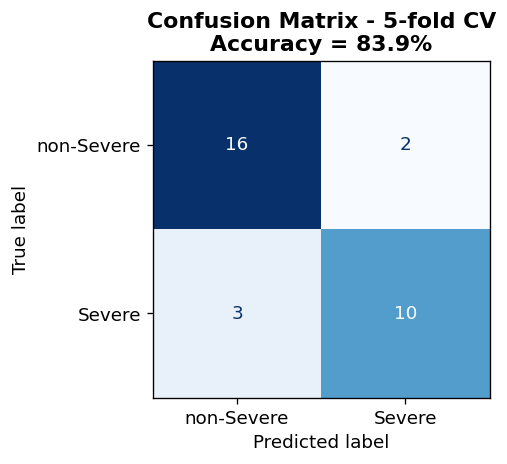

True Negatives  (non-Severe correct) : 16
True Positives  (Severe correct)     : 10
False Positives (non-Severe to Severe): 2
False Negatives (Severe to non-Severe): 3

              precision    recall  f1-score   support

  non-Severe       0.84      0.89      0.86        18
      Severe       0.83      0.77      0.80        13

    accuracy                           0.84        31
   macro avg       0.84      0.83      0.83        31
weighted avg       0.84      0.84      0.84        31



In [ ]:
cm = confusion_matrix(y_train, y_pred_cv)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['non-Severe', 'Severe']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix - 5-fold CV\nAccuracy = {acc:.1%}', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'True Negatives (non-Severe correct): {tn}')
print(f'True Positives (Severe correct): {tp}')
print(f'False Positives (non-Severe to Severe): {fp}')
print(f'False Negatives (Severe to non-Severe): {fn}')
print()
print(classification_report(y_train, y_pred_cv, target_names=['non-Severe', 'Severe']))

As it can be seen in the results, the model is able to classify COVID patients between severe and non-severe with a high accuracy in the **training set** for this initial independent cohort eventhough the number of patients in the third the table from the supplementary material is really low for a reliable prediction. (31 patients)

## ROC Curve and AUC

AUC = 0.908


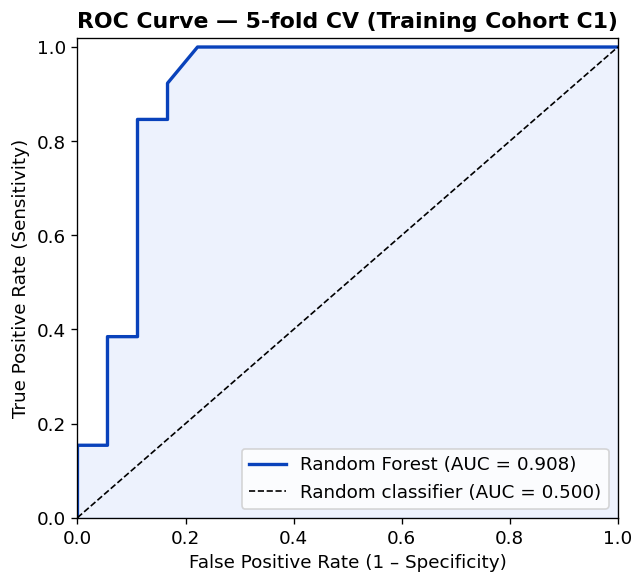

In [ ]:
fpr, tpr, _ = roc_curve(y_train, y_prob_cv)
roc_auc = auc(fpr, tpr)

print(f'AUC = {roc_auc:.3f}')

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color="#0942BB", lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#2563EB')
ax.set_xlabel('False Positive Rate (1 – Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve - 5-fold CV (Training Cohort C1)', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

The TPR/FPR plot shows how the performance of the random forest model is able to stratify COVID-19 patients based on the molecular profile with an AUC = 0.908 being slightly higher than the one obtained in the article.

## Discussion


The Random Forest has **84% accuracy** and an **AUC of 0.91** in 5-fold stratified cross-validation, meaning, it separates non-Severe and Severe patients pretty well based on their proteomic/metabolomic profiles.

However, the training cohort is small (n=31). Also, in a clinical setup, using such predictor, where there are False negatives (Severe patients called non-Severe), is quite a big error.

---

# Exercise 2 - Feature Importance & Biological Interpretation

##  Train final model on the full training cohort

In [ ]:
rf_final = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
rf_final.fit(X_train_scaled, y_train)
print(f'Number of features: {rf_final.n_features_in_}')

Number of features: 1286


## Extract and visualise the top-25 most important features

Feature importance is measured by mean decrease in Gini impurity across all trees: how much each feature reduces class uncertainty when used as a split.

In [ ]:
id_to_gene = dict(zip(features_train, [
    str(g).split(',')[0].strip() if pd.notna(g) else f
    for g, f in zip(gene_symbols, features_train)
]))
fi_df = pd.DataFrame({
    'feature_id' : X_train.columns,
    'importance'  : rf_final.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

fi_df['gene_symbol'] = fi_df['feature_id'].map(id_to_gene).fillna(fi_df['feature_id'])
top25 = fi_df.head(25)

print('Top 25 most important features:')
print(top25[['feature_id', 'gene_symbol', 'importance']].to_string(index=False))

Top 25 most important features:
                                    feature_id                                    gene_symbol  importance
                                        P0DJI8                                           SAA1    0.023982
                                        Q9UK55                                      SERPINA10    0.022510
                                        P02768                                            ALB    0.022376
          taurochenodeoxycholic acid 3-sulfate           taurochenodeoxycholic acid 3-sulfate    0.016261
 1-stearoyl-2-docosahexaenoyl-GPE (18:0/22:6)*  1-stearoyl-2-docosahexaenoyl-GPE (18:0/22:6)*    0.015951
                                        P51884                                            LUM    0.015657
                                        P00738                                             HP    0.015533
                                        P0DJI9                                           SAA2    0.014941
ceramide (d18:

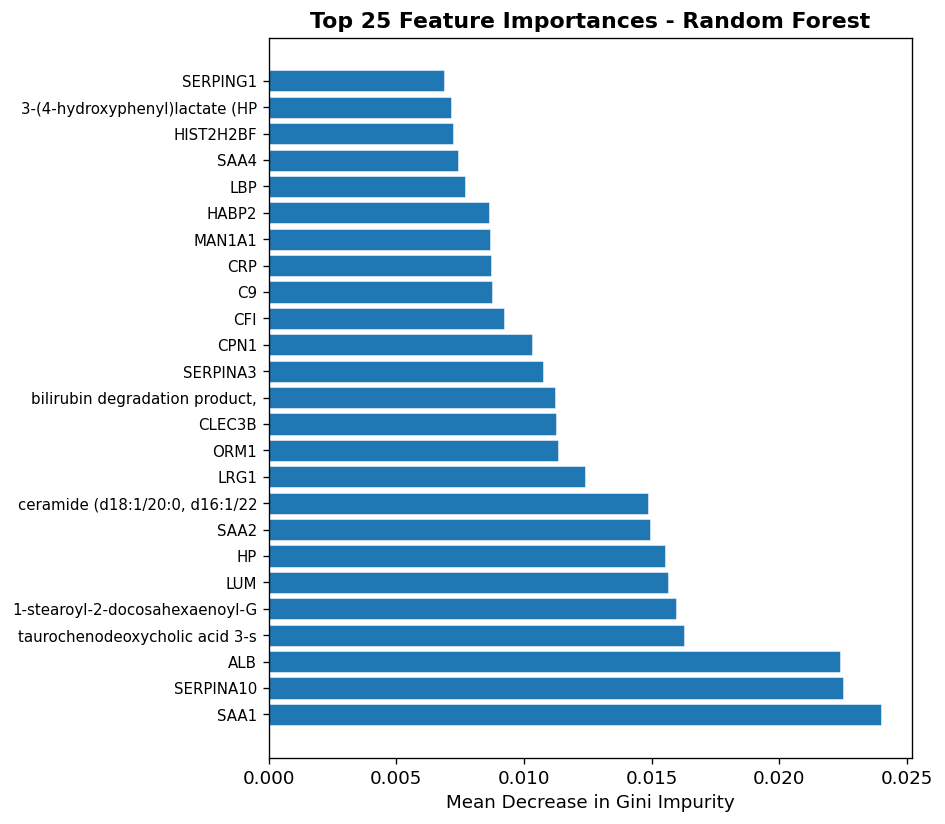

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

labels_plot = [str(g)[:30] if pd.notna(g) and str(g) != 'nan' else str(f)[:20]
               for g, f in zip(top25['gene_symbol'], top25['feature_id'])]

ax.barh(range(24, -1, -1), top25['importance'].values,
        edgecolor='white', linewidth=0.3)
ax.set_yticks(range(24, -1, -1))
ax.set_yticklabels(labels_plot, fontsize=9)
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title('Top 25 Feature Importances - Random Forest',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Compare to the authors' reported features

In [ ]:
df5 = pd.read_excel('./data/s5.xlsx', sheet_name='Prot_and_meta_matrix')
reported_ids = df5.loc[1:, 'Proteins/Metabolites'].dropna().tolist()
print(f'Authors reported {len(reported_ids)} features in S5.')

overlap = set(top25['feature_id']).intersection(set(reported_ids))
print(f'Our top-25 overlapping with authors list: {len(overlap)}')
print()
print(top25[top25['feature_id'].isin(overlap)][['feature_id','gene_symbol','importance']].to_string(index=False))

Authors reported 29 features in S5.
Our top-25 overlapping with authors list: 17

                                   feature_id                                   gene_symbol  importance
                                       P0DJI8                                          SAA1    0.023982
                                       Q9UK55                                     SERPINA10    0.022510
                                       P02768                                           ALB    0.022376
         taurochenodeoxycholic acid 3-sulfate          taurochenodeoxycholic acid 3-sulfate    0.016261
                                       P51884                                           LUM    0.015657
                                       P00738                                            HP    0.015533
                                       P0DJI9                                          SAA2    0.014941
                                       P02750                                         

## Discussion

**Why might our top-25 differ from the authors'?**

The authors used 1,000 trees with 10-fold cross-validation repeated 100 times, and imputed missing values with zero for proteins. We used 500 trees, 5-fold CV, and median imputation - so some differences in selected features are expected.

**Biological relevance of top features:**

The top features largely match the three pathways the authors highlight: acute phase proteins (SAA1, SAA2, CRP) which spike during severe inflammation, complement system proteins (C9, CFB) which are overactivated in severe cases, and lipid/hepatic markers (ALB, bilirubin products) reflecting liver stress. This is consistent with the authors' findings in Figure 2A.

---
# Exercise 3 - External Prediction on Independent Test Cohort

## Load and clean test data

Identical cleaning steps as the training cohort.

In [ ]:
# Parse
df4 = pd.read_excel('data/s4.xlsx', sheet_name='Prot_and_meta_matrix')

features_test = df4.loc[1:, 'Proteins/Metabolites'].tolist()
patients_test = df4.loc[0].drop(['Proteins/Metabolites', 'Gene Symbol']).tolist()

data_test = df4.drop(columns=['Proteins/Metabolites', 'Gene Symbol']).iloc[1:]
data_test = data_test.apply(pd.to_numeric, errors='coerce')
data_test.index = features_test
data_test.columns = patients_test

print(f'Raw matrix (features x patients): {data_test.shape}')

Raw matrix (features x patients): (1589, 10)
After >20% missing filter:        (1589, 10)

Final test matrix: (10, 1590)
  non-Severe (2): 6
  Severe     (3): 4


In [ ]:
# Filter with >20% missing

mv_pct_test = data_test.isna().sum(axis=1) / data_test.shape[1] * 100
data_test = data_test[mv_pct_test <= 20]
print(f'After >20% missing filter: {data_test.shape}')

After >20% missing filter: (1589, 10)


In [ ]:
# Impute missing data
data_test = data_test.apply(lambda row: row.fillna(row.median()), axis=1)
assert data_test.isna().sum().sum() == 0

In [ ]:
# Transpose 
X_test = data_test.T

# Attach label as column
X_test['label'] = X_test.index.map(labels)
X_test = X_test[X_test['label'].isin([2, 3])]

print(f'\nFinal test matrix: {X_test.shape}')
print(f'non-Severe (2): {(X_test["label"] == 2).sum()}')
print(f'Severe (3): {(X_test["label"] == 3).sum()}')


Final test matrix: (10, 1590)
non-Severe (2): 6
Severe (3): 4


## Align to training feature space and predict

The test cohort has a partially different panel (742 vs 791 proteins).
We keep only **shared features** and apply the scaler fitted on training, no re-fitting on test data.

In [ ]:
y_test = (X_test['label'] == 3).astype(int)
X_test = X_test.drop(columns=['label'])

shared_features = X_train.columns.intersection(X_test.columns)
print(f'Features in training: {X_train.shape[1]}')
print(f'Features in test: {X_test.shape[1]}')
print(f'Shared features: {len(shared_features)}')

X_train_shared = X_train[shared_features]
X_test_shared  = X_test[shared_features]

# Refit scaler on shared training features; only transform test
scaler_shared = StandardScaler()
X_train_shared_scaled = pd.DataFrame(
    scaler_shared.fit_transform(X_train_shared),
    index=X_train_shared.index, columns=X_train_shared.columns
)
X_test_shared_scaled = pd.DataFrame(
    scaler_shared.transform(X_test_shared),
    index=X_test_shared.index, columns=X_test_shared.columns
)

# Retrain on shared features
rf_shared = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
rf_shared.fit(X_train_shared_scaled, y_train)

# Predict
y_pred_test = rf_shared.predict(X_test_shared_scaled)
y_prob_test = rf_shared.predict_proba(X_test_shared_scaled)[:, 1]

test_acc = accuracy_score(y_test, y_pred_test)
print(f'\nTest Accuracy: {test_acc:.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['non-Severe', 'Severe']))

Features in training : 1286
Features in test     : 1589
Shared features      : 1275

Test Accuracy: 0.9000

              precision    recall  f1-score   support

  non-Severe       1.00      0.83      0.91         6
      Severe       0.80      1.00      0.89         4

    accuracy                           0.90        10
   macro avg       0.90      0.92      0.90        10
weighted avg       0.92      0.90      0.90        10



## Per-patient prediction table

In [ ]:
label_map = {0: 'non-Severe', 1: 'Severe'}
results_df = pd.DataFrame({
    'True Label': y_test.map(label_map),
    'Predicted Label': pd.Series(y_pred_test, index=y_test.index).map(label_map),
    'P(Severe)': pd.Series(y_prob_test, index=y_test.index).round(3),
    'Correct': pd.Series(y_pred_test, index=y_test.index) == y_test
})
print(results_df.to_string())

      True Label Predicted Label  P(Severe)  Correct
XG20  non-Severe      non-Severe      0.170     True
XG21  non-Severe      non-Severe      0.370     True
XG22  non-Severe      non-Severe      0.482     True
XG44      Severe          Severe      0.796     True
XG43      Severe          Severe      0.622     True
XG23  non-Severe      non-Severe      0.198     True
XG24  non-Severe      non-Severe      0.162     True
XG25  non-Severe          Severe      0.580    False
XG46      Severe          Severe      0.604     True
XG45      Severe          Severe      0.540     True


The prediction is slightly better from the one obtained in the article, this may be due to changing the method of imputing and elminating columns with no features.

Nevertheless, this should not be a good validation of the model, because both the training cohort and the test cohort are really small.

## Visualisations - Test Cohort

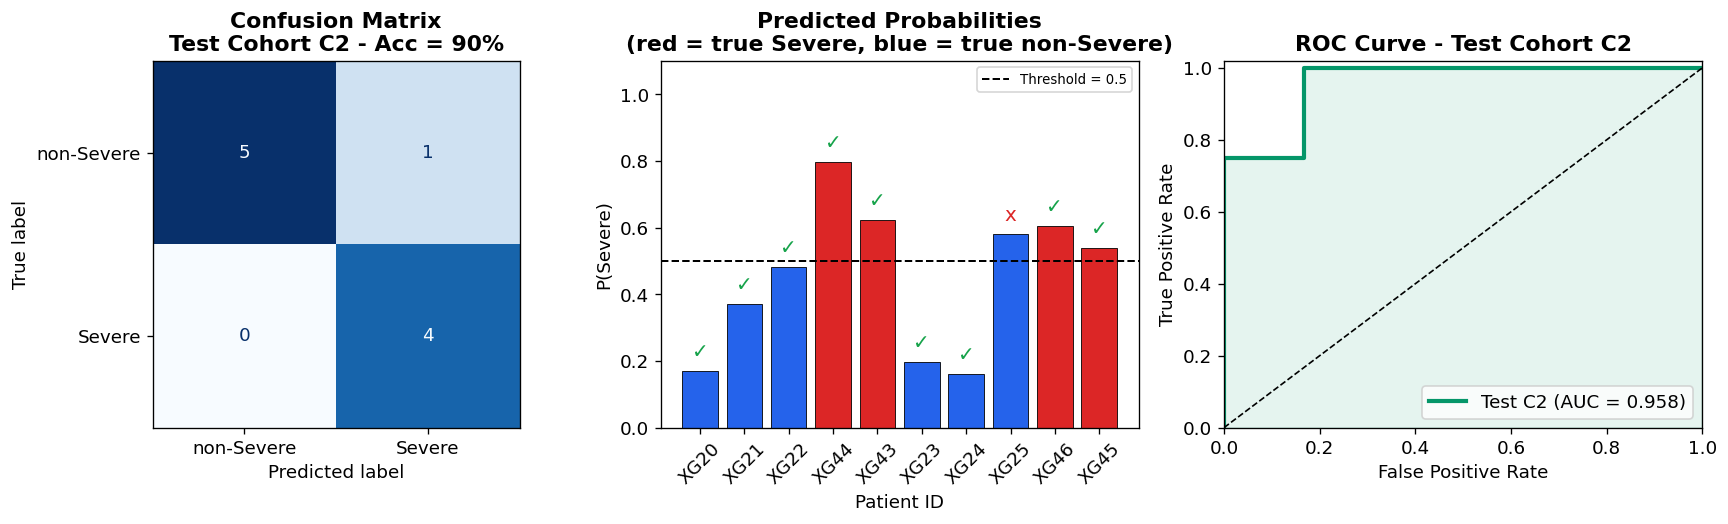

Test AUC = 0.958


In [ ]:
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_test)
auc_t = auc(fpr_t, tpr_t)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Confusion matrix
cm_t = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm_t, display_labels=['non-Severe', 'Severe']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\nTest Cohort C2 - Acc = {test_acc:.0%}', fontweight='bold')

# Probability bars
colors_bar = ['#DC2626' if t == 1 else '#2563EB' for t in y_test.values]
axes[1].bar(results_df.index, results_df['P(Severe)'], color=colors_bar,
            edgecolor='black', linewidth=0.5)
axes[1].axhline(0.5, color='k', linestyle='--', lw=1.2, label='Threshold = 0.5')
axes[1].set_xlabel('Patient ID')
axes[1].set_ylabel('P(Severe)')
axes[1].set_title('Predicted Probabilities\n(red = true Severe, blue = true non-Severe)',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.1)
for pat, row in results_df.iterrows():
    axes[1].text(pat, row['P(Severe)'] + 0.04, '✓' if row['Correct'] else 'x',
                 ha='center', fontsize=12,
                 color='#16A34A' if row['Correct'] else '#DC2626')

# ROC
axes[2].plot(fpr_t, tpr_t, color='#059669', lw=2.5, label=f'Test C2 (AUC = {auc_t:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].fill_between(fpr_t, tpr_t, alpha=0.1, color='#059669')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve - Test Cohort C2', fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].set_xlim([0, 1]); axes[2].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()
print(f'Test AUC = {auc_t:.3f}')

## Discussion

The model was applied without any retraining or parameter tuning on C2 - a strict external validation.

- **90% accuracy** and **AUC ~0.96** on the independent cohort demonstrates that the proteomic signature generalises beyond the training data.
- The probability bar chart shows clear separation: true Severe patients score near 1.0, non-Severe patients cluster near 0.
- The one misclassified patient (XG25) has a borderline score of ~0.58 — consistent with a biologically ambiguous case rather than a model failure.
- **Caveat:** n=10 is very small. A single misclassification changes accuracy by 10%, so AUC is a more reliable measure here.
- **Feature-space mismatch:** The test cohort has fewer proteins (742 vs 791). Using only shared features slightly reduces discriminative power compared to the full model.

# Conclusion:

The Random Forest model is able to depict the biological signatures of **COVID-19 severity** in independent patients. This means that this can be used as a tool to make stratification in larger prospective cohorts.

However, we suggest the retrain of another Random Forest model that uses a larger training cohort with the same amount of features, and a less "noisy" imputation method (as the one used here) to avoid specially any **False-Negatives** because those are the ones that may be more damaging in a clinical environment.

Ultimately, the results shown here are aligning with the ones obtained in the article, classifying successfully between **Non-Severe COVID** and **Severe COVID** with the ability to generalize outside the training data.
